In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
from pathlib import Path


def resolve_data_path():
    cwd = Path.cwd().resolve()
    relative_candidates = [Path("parkdaten.csv"), Path("data") / "parkdaten.csv"]
    for base in [cwd, *cwd.parents]:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Could not find parkdaten.csv from {cwd}")


data_path = resolve_data_path()
df = pd.read_csv(data_path, sep=";")
df.head()

,Parkplatz,12:30,12:45,13:00,13:15,13:30,13:45,14:00,14:15,14:30
0,1,I-7009AU,I-7009AU,I-7009AU,I-7009AU,I-7009AU,I-7009AU,I-7009AU,I-7009AU,I-7009AU
1,2,I-6455AT,I-6455AT,IL-900BI,leer,leer,IL-498RP,leer,leer,leer
2,3,leer,I-3467AX,I-3467AX,I-3467AX,I-3467AX,I-3467AX,I-3467AX,I-3467AX,I-3467AX
3,4,I-7985AT,I-7985AT,I-7985AT,I-7985AT,I-7985AT,I-7985AT,I-7985AT,I-7985AT,I-7985AT
4,5,I-6242AS,I-6242AS,I-6242AS,I-6242AS,I-6242AS,I-6242AS,I-6242AS,I-6242AS,I-6242AS


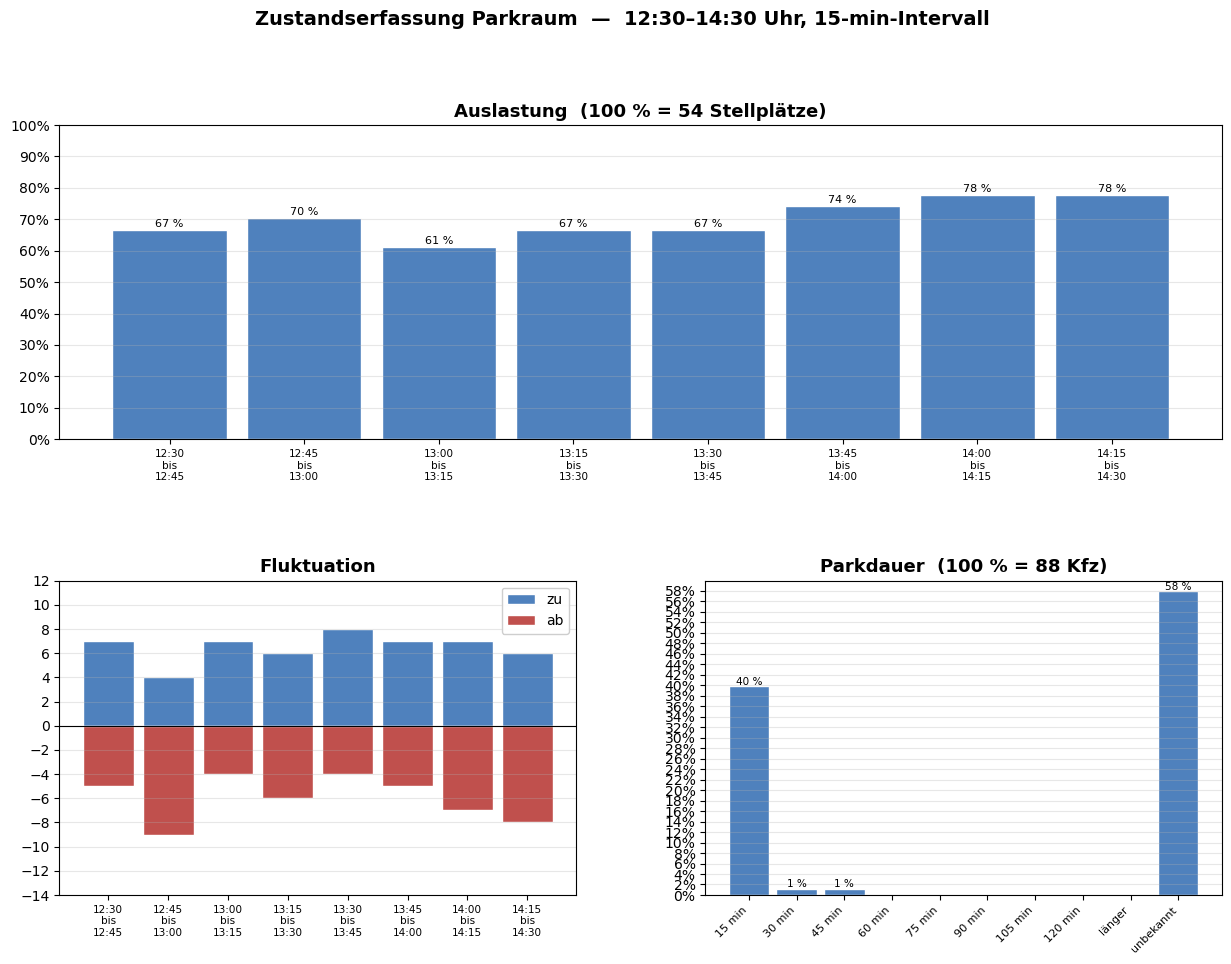

Mittlere Auslastung: 70.1 %  (Min 61 %, Max 78 %)
Σ Zugänge: 52,  Σ Abgänge: 48,  Σ Aufenthalte: 88
Anteil "unbekannt" (Dauerparker am Rand): 58 %


In [13]:
# =============================================================================
# Programm 2 — Zustandserfassung Parkraum (Darstellung wie Vorlesungsfolie)
#   1) Auslastung   (% Belegung je 15-min-Intervall)
#   2) Fluktuation  (Zugänge "zu" und Abgänge "ab" zwischen den Intervallen)
#   3) Parkdauer    (% der Aufenthalte je Dauerklasse)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def resolve_data_path():
    cwd = Path.cwd().resolve()
    relative_candidates = [Path("parkdaten.csv"), Path("data") / "parkdaten.csv"]
    for base in [cwd, *cwd.parents]:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Could not find parkdaten.csv from {cwd}")


park = pd.read_csv(resolve_data_path(), sep=';')
times = list(park.columns[1:]); n_t, n_p = len(times), len(park)

# Belegungs-Matrix (True = belegt)
occ = np.array([[park.iloc[i,j+1] != 'leer' for j in range(n_t)] for i in range(n_p)])

# 1) AUSLASTUNG  ───────────────────────────────────────────────────────────────
ausl = occ.sum(axis=0) / n_p * 100
ausl_labels = [f'{times[j]}\nbis\n{times[j+1] if j+1<n_t else "—"}' for j in range(n_t-1)]
ausl_intvl  = ausl[:-1]   # ein Balken je Intervall (n-1 Balken)

# 2) FLUKTUATION ──────────────────────────────────────────────────────────────
zu = np.zeros(n_t-1, dtype=int); ab = np.zeros(n_t-1, dtype=int)
for j in range(n_t-1):
    for i in range(n_p):
        a = park.iloc[i,j+1]; b = park.iloc[i,j+2]
        if a == 'leer' and b != 'leer':       zu[j] += 1
        elif a != 'leer' and b == 'leer':     ab[j] += 1
        elif a != 'leer' and b != 'leer' and a != b:
            zu[j] += 1; ab[j] += 1
fluk_labels = ausl_labels   # gleiche Intervalle

# 3) PARKDAUER ────────────────────────────────────────────────────────────────
stays = []   # (länge_in_intervallen, links zensiert, rechts zensiert)
for i in range(n_p):
    j = 0
    while j < n_t:
        if park.iloc[i,j+1] == 'leer': j += 1; continue
        k = j; cl = (j == 0)
        while k < n_t and park.iloc[i,k+1] == park.iloc[i,j+1]: k += 1
        cr = (k == n_t)
        stays.append((k-j, cl, cr)); j = k
n_stays = len(stays)

bins = list(range(15, 121, 15)) + ['länger','unbekannt']
counts = {b: 0 for b in bins}
for length, cl, cr in stays:
    dur = length * 15
    if cl or cr:           counts['unbekannt'] += 1
    elif dur in counts:    counts[dur] += 1
    else:                  counts['länger'] += 1
pct = {b: counts[b]/n_stays*100 for b in bins}

# ── Plot ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.45, wspace=0.25)
ax_a = fig.add_subplot(gs[0, :])    # Auslastung (oben, breit)
ax_f = fig.add_subplot(gs[1, 0])    # Fluktuation
ax_d = fig.add_subplot(gs[1, 1])    # Parkdauer

# 1) Auslastung
ax_a.bar(range(len(ausl_intvl)), ausl_intvl, color='#4F81BD',
         edgecolor='white', width=0.85)
ax_a.set_xticks(range(len(ausl_labels)))
ax_a.set_xticklabels(ausl_labels, fontsize=7.5)
ax_a.set_yticks(range(0, 101, 10))
ax_a.set_yticklabels([f'{v}%' for v in range(0,101,10)])
ax_a.set_ylim(0, 100)
ax_a.set_title(f'Auslastung  (100 % = {n_p} Stellplätze)',
               fontsize=13, fontweight='bold')
ax_a.grid(axis='y', alpha=0.3)
for i, v in enumerate(ausl_intvl):
    ax_a.text(i, v+1, f'{v:.0f} %', ha='center', fontsize=8)

# 2) Fluktuation (zu = positiv blau, ab = negativ rot)
x = np.arange(len(zu))
ax_f.bar(x, zu, color='#4F81BD', label='zu',  edgecolor='white', width=0.85)
ax_f.bar(x, -ab, color='#C0504D', label='ab', edgecolor='white', width=0.85)
ax_f.axhline(0, color='black', lw=0.8)
ax_f.set_xticks(x); ax_f.set_xticklabels(fluk_labels, fontsize=7.5)
yabs = max(zu.max(), ab.max()) + 2
ax_f.set_ylim(-yabs, yabs)
ax_f.set_yticks(range(-int(yabs)//2*2-2, int(yabs)//2*2+3, 2))
ax_f.set_title('Fluktuation', fontsize=13, fontweight='bold')
ax_f.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax_f.grid(axis='y', alpha=0.3)

# 3) Parkdauer (% der Aufenthalte)
labels = [f'{b} min' if isinstance(b,int) else b for b in bins]
vals = [pct[b] for b in bins]
ax_d.bar(range(len(bins)), vals, color='#4F81BD', edgecolor='white', width=0.85)
ax_d.set_xticks(range(len(bins)))
ax_d.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ymax = max(20, max(vals)+2)
ax_d.set_yticks(np.arange(0, ymax+1, 2))
ax_d.set_yticklabels([f'{int(v)}%' for v in np.arange(0, ymax+1, 2)])
ax_d.set_ylim(0, ymax)
ax_d.set_title(f'Parkdauer  (100 % = {n_stays} Kfz)',
               fontsize=13, fontweight='bold')
ax_d.grid(axis='y', alpha=0.3)
for i, v in enumerate(vals):
    if v > 0: ax_d.text(i, v+0.3, f'{v:.0f} %', ha='center', fontsize=7.5)

fig.suptitle('Zustandserfassung Parkraum  —  12:30–14:30 Uhr, 15-min-Intervall',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

print(f'Mittlere Auslastung: {ausl_intvl.mean():.1f} %  '
      f'(Min {ausl_intvl.min():.0f} %, Max {ausl_intvl.max():.0f} %)')
print(f'Σ Zugänge: {zu.sum()},  Σ Abgänge: {ab.sum()},  Σ Aufenthalte: {n_stays}')
print(f'Anteil "unbekannt" (Dauerparker am Rand): {pct["unbekannt"]:.0f} %')